# EX 1B – Baseball Databank

Same Random Forest regression workflow as the friend's EX 1B, adapted to predict player-season runs from Baseball batting statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

df = pd.read_csv(find_data("Batting.csv"))
df.head()

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (101332, 22)

Columns:
['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']

Data Types:
playerID     object
yearID        int64
stint         int64
teamID       object
lgID         object
G             int64
AB          float64
R           float64
H           float64
2B          float64
3B          float64
HR          float64
RBI         float64
SB          float64
CS          float64
BB          float64
SO          float64
IBB         float64
HBP         float64
SH          float64
SF          float64
GIDP        float64
dtype: object


In [4]:
missing_values = df.isnull().sum()
print(missing_values)

playerID        0
yearID          0
stint           0
teamID          0
lgID          737
G               0
AB           5149
R            5149
H            5149
2B           5149
3B           5149
HR           5149
RBI          5573
SB           6449
CS          28603
BB           5149
SO          12987
IBB         41712
HBP          7959
SH          11487
SF          41181
GIDP        31257
dtype: int64


In [5]:
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicate rows removed:", before - after)

Rows before removing duplicates: 101332
Rows after removing duplicates: 101332
Duplicate rows removed: 0


In [6]:
features = [
    "yearID", "stint", "G", "AB", "H", "2B", "3B", "HR",
    "RBI", "BB", "SO", "SB"
]
target = "R"

for col in features + [target]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=features + [target]).copy()

print("Selected features:", features)
print("Target:", target)
print("Prepared dataset shape:", df.shape)

Selected features: ['yearID', 'stint', 'G', 'AB', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB']
Target: R
Prepared dataset shape: (87045, 22)


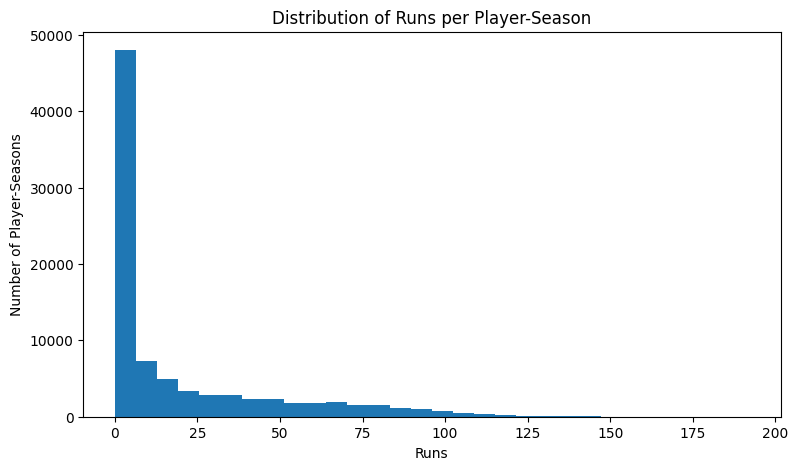

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(df["R"], bins=30)
plt.title("Distribution of Runs per Player-Season")
plt.xlabel("Runs")
plt.ylabel("Number of Player-Seasons")
plt.show()

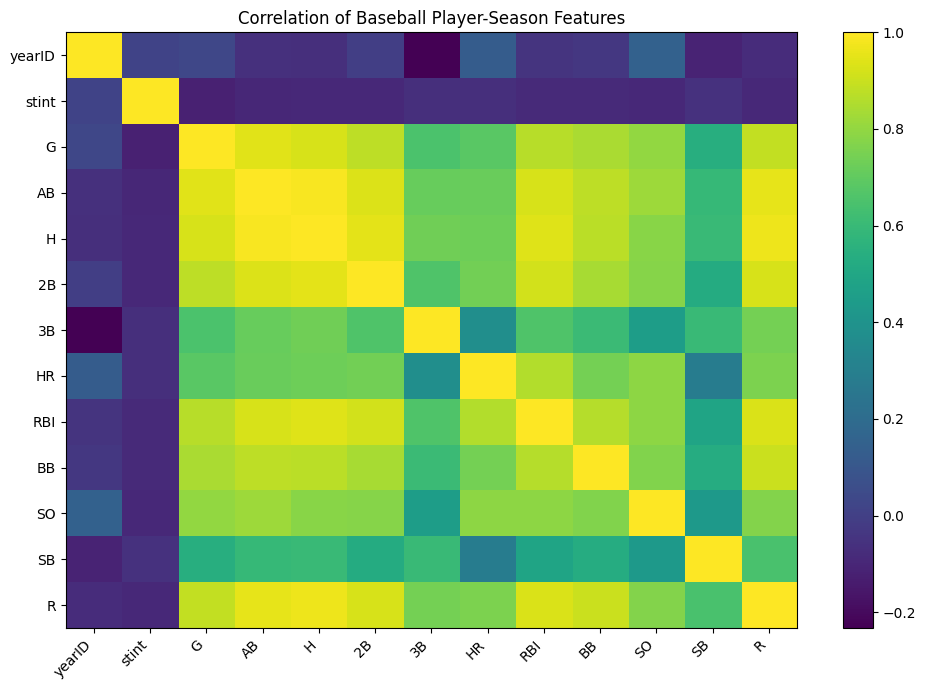

In [8]:
corr = df[features + [target]].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation of Baseball Player-Season Features")
plt.tight_layout()
plt.show()

In [9]:
X = df[features]
y = df[target]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 input records:")
display(X.head())
print("\nFirst 5 target values:")
display(y.head())

Input shape: (87045, 12)
Target shape: (87045,)

First 5 input records:


,yearID,stint,G,AB,H,2B,3B,HR,RBI,BB,SO,SB
0,1871,1,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1871,1,25,118.0,32.0,6.0,0.0,0.0,13.0,4.0,0.0,8.0
2,1871,1,29,137.0,40.0,4.0,5.0,0.0,19.0,2.0,5.0,3.0
3,1871,1,27,133.0,44.0,10.0,2.0,2.0,27.0,0.0,2.0,1.0
4,1871,1,25,120.0,39.0,11.0,3.0,0.0,16.0,2.0,1.0,6.0



First 5 target values:


0     0.0
1    30.0
2    28.0
3    28.0
4    29.0
Name: R, dtype: float64

In [10]:
sample_size = min(50000, len(df))
model_df = df.sample(n=sample_size, random_state=42)

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 40000
Testing records: 10000


In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Random Forest model trained successfully")

Random Forest model trained successfully


In [12]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Runs": y_test.to_numpy()[:15],
    "Predicted Runs": np.round(y_pred[:15], 2)
})

comparison

,Actual Runs,Predicted Runs
0,1.0,3.27
1,2.0,3.73
2,0.0,0.00
3,61.0,65.85
4,13.0,5.60
5,24.0,13.49
6,6.0,12.12
7,39.0,40.11
8,4.0,1.16
9,87.0,96.36


In [13]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2.6882
R² Score: 0.9713


In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
4,H,0.939965
9,BB,0.018844
0,yearID,0.008356
11,SB,0.007274
7,HR,0.006796
8,RBI,0.003764
2,G,0.003632
3,AB,0.003124
10,SO,0.002794
6,3B,0.002715
